In [1]:
import sys
sys.path.append('../')

import numpy as np
import scipy.sparse as ssp
import matplotlib.pyplot as plt
import qutip as qt
import scqubits as scq
from matplotlib.colors import LogNorm
from tqdm import tqdm
from qutip.qip.operations import rz, cz_gate
import cmath
from sympy import symbols
import utils_2Q_gate_zp as ut
ut.set_fig_font() ### Set various sizes in plotting
import scipy as sp
from joblib import Parallel, delayed
import itertools
from qutip.qip.operations import rz, cz_gate, cnot, rx, hadamard_transform, swap
import pandas as pd

## Prepare two zero pi 

In [2]:
args_all = ut.get_operator_two_zeropi()

In [6]:
[n_theta1, n_theta2, n_theta1_dress, n_theta2_dress, n_theta1_truc, n_theta2_truc,
eval_tot, order_sort, H0, trunc_states, eket0, eket1, eket_tot  ] = args_all

truc = len(trunc_states)
state_tot = [qt.basis(truc, i) for i in range(truc)]

e_ops = [qt.basis(truc, i) * qt.basis(truc, i).dag()
        for i in range(truc)]

# Trans ;  w_ij;    n_theta1; n_theta2; sum
# 00-14 ;  45.925 ;  0.032 ;  0.006 ;  0.038
# 20-14 ;  24.289 ;  0.046 ;  0.001 ;  0.047
logi_space = ['00', '02', '20', '22']
[ w_00_14, w_20_14, n_theta1_00_14, n_theta2_00_14,
n_theta1_20_14, n_theta2_20_14] = ut.get_transition_freq_cnot(args_all)

H_qbt_drive = [ H0, [2*np.pi*n_theta1_truc, ut.drive_gauss_A],
                    [2*np.pi*n_theta1_truc, ut.drive_gauss_B]  ]

n1n1 = True
args = (w_00_14, w_20_14, n_theta1_00_14, n_theta2_00_14,
        n_theta1_20_14, n_theta2_20_14, state_tot, H_qbt_drive, n1n1)
idxs = [order_sort.index(i) for i in trunc_states]



## Infidelity(tg) - 2A0

In [4]:
H_qbt_drive = [ H0, [2*np.pi*n_theta1_truc, ut.drive_gauss_A],
                    [2*np.pi*n_theta1_truc, ut.drive_gauss_B]  ]
n1n1 = True
args = (w_00_14, w_20_14, n_theta1_00_14, n_theta2_00_14, n_theta1_20_14,
    n_theta2_20_14, state_tot, H_qbt_drive, n1n1)

2it [00:01,  1.12it/s]
2it [00:01,  1.06it/s]


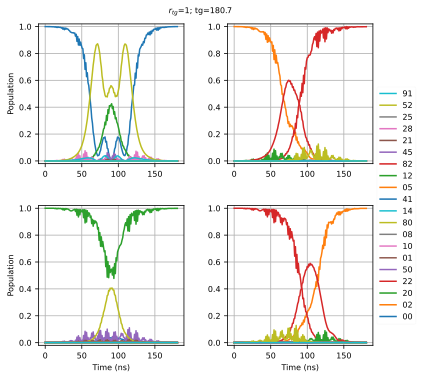

In [7]:
[tg, drive_amp_A, drive_amp_B, 
 detune_A, detune_B] = [ 180.72, 0.18575447, 0.03809189, -0.29511013, -0.3287981]
# [110.0,0.07457781,0.06346544,-0.26346294,-0.25926915]
options = qt.Options(store_states=True)
r_tg = 1
tlist = np.linspace(0, tg, num=int(r_tg*tg))  # total time
pulse_args = {'drive_amp_A': drive_amp_A* (n_theta1_20_14/n_theta1_00_14) ,
            'drive_freq_A': w_00_14 + 2*np.pi*detune_A,
            'drive_amp_B': drive_amp_B ,
            'drive_freq_B': w_20_14 + 2*np.pi*detune_B,
            'gate_time': tg }

[w_00_14, w_20_14, n_theta1_00_14, n_theta2_00_14, n_theta1_20_14,
n_theta2_20_14] = ut.get_transition_freq_cnot(args_all)
H_qbt_drive = [ H0, [2*np.pi*n_theta1_truc, ut.drive_gauss_A],
                    [2*np.pi*n_theta1_truc, ut.drive_gauss_B]  ]
result = {}
logi_state = [0,2]
for idx, state_i in enumerate(logi_state):
    for jdx, state_j in tqdm(enumerate(logi_state)):
        # This simulation is just for viewing the affect of the pulse
        result[idx, jdx] = qt.mesolve(
            H_qbt_drive,
            qt.basis(truc, trunc_states.index( str(state_i) + str(state_j) )),
            tlist,
            e_ops=[state * state.dag() for state in state_tot],
            args=pulse_args,options=options  )

#####################################################################################
##### Drive and Population Visualization #######
fig, ax = plt.subplots(figsize=(6,5.8), nrows=2, ncols=2)
#ax[0].plot(tlist, drive)
fig.suptitle('$r_{tg}$=%d'%r_tg+ '; tg=%.1f'%tg, y=0.92)
plt.subplots_adjust(wspace=0.3, hspace=0.3)
order = ['(a)', '(b)','(c)','(d)']
for idx, state_i in enumerate(logi_state):
    for jdx, state_j in enumerate(logi_state):
        for kdx, res in zip(idxs, result[idx,jdx].expect):
            ax[idx][jdx].plot(tlist, res, label=r"%s" % order_sort[kdx])
        ax[idx][jdx].set_ylim(-0.02,1.02)
        ax[idx][jdx].grid()
        # ax[idx][jdx].set_title('initial state=|'+str(state_i)+str(state_j)+'>')
        # ax[idx][jdx].text(0.05, 0.93, order[2*idx+jdx], transform=ax[idx][jdx].transAxes,  va='top')
    ax[1][idx].set_xlabel('Time (ns)')
    ax[idx][0].set_ylabel('Population')
handles, labels = ax[1][1].get_legend_handles_labels()
ax[1][1].legend(handles[::-1],labels[::-1],
                loc='center left',
                bbox_to_anchor=(1, 1)).get_frame().set_alpha(0.1)
# plt.savefig('../image/zp_cz_full_simulate.png',dpi=150,bbox_inches='tight')

In [8]:
transposed_list = list(zip(*result[1,0].expect))
df = pd.DataFrame(transposed_list, columns=trunc_states)
# df.to_csv('data/cnot_population_20.txt', sep=',', index=True, header=True)

In [9]:
tg, drive_amp_1, drive_amp_2, detune_1, detune_2 = 180.72, 0.18575447, 0.03809189, -0.29511013, -0.3287981
detune_vec = np.linspace(-0.0025, 0.0025, 51)[:-2]
values_grid = list(itertools.product([drive_amp_1], [drive_amp_2], [tg],
                                     detune_vec + detune_1, [detune_2]))
fidelity_w1 = Parallel(n_jobs=len(detune_vec), verbose=1)(delayed(ut.get_fidelity_cnot_2A0)(arg_de, *args)
                                            for arg_de in values_grid)

error_w1 = 10**np.array(fidelity_w1)
values_grid = list(itertools.product([drive_amp_1], [drive_amp_2], [tg],
                                     [detune_1], detune_vec + detune_2))
fidelity_w2 = Parallel(n_jobs=len(detune_vec), verbose=1)(delayed(ut.get_fidelity_cnot_2A0)(arg_de, *args)
                                            for arg_de in values_grid)
error_w2 = 10**np.array(fidelity_w2)

A_vec = np.linspace(-0.0025, 0.0025, 51)[:-2]
values_grid = list(itertools.product(A_vec + drive_amp_1, [drive_amp_2], [tg], [detune_1], [detune_2]))
fidelity_A1 = Parallel(n_jobs=len(A_vec), verbose=1)(delayed(ut.get_fidelity_cnot_2A0)(arg_de, *args)
                                            for arg_de in values_grid)
error_A1 = 10**np.array(fidelity_A1)

values_grid = list(itertools.product([drive_amp_1], A_vec + drive_amp_2, [tg], [detune_1], [detune_2]))
fidelity_A2 = Parallel(n_jobs=len(A_vec), verbose=1)(delayed(ut.get_fidelity_cnot_2A0)(arg_de, *args)
                                            for arg_de in values_grid)
error_A2 = 10**np.array(fidelity_A2)

[Parallel(n_jobs=49)]: Using backend LokyBackend with 49 concurrent workers.


[Parallel(n_jobs=49)]: Done   1 tasks      | elapsed:    6.6s
[Parallel(n_jobs=49)]: Done   2 out of  49 | elapsed:    6.8s remaining:  2.7min
[Parallel(n_jobs=49)]: Done  49 out of  49 | elapsed:    8.4s finished
[Parallel(n_jobs=49)]: Using backend LokyBackend with 49 concurrent workers.
[Parallel(n_jobs=49)]: Done   1 tasks      | elapsed:    4.1s
[Parallel(n_jobs=49)]: Done   2 out of  49 | elapsed:    4.1s remaining:  1.6min
[Parallel(n_jobs=49)]: Done  49 out of  49 | elapsed:    5.3s finished
[Parallel(n_jobs=49)]: Using backend LokyBackend with 49 concurrent workers.
[Parallel(n_jobs=49)]: Done   1 tasks      | elapsed:    4.1s
[Parallel(n_jobs=49)]: Done   2 out of  49 | elapsed:    4.2s remaining:  1.7min
[Parallel(n_jobs=49)]: Done  49 out of  49 | elapsed:    5.7s finished
[Parallel(n_jobs=49)]: Using backend LokyBackend with 49 concurrent workers.
[Parallel(n_jobs=49)]: Done   1 tasks      | elapsed:    4.0s
[Parallel(n_jobs=49)]: Done   2 out of  49 | elapsed:    4.0s rem

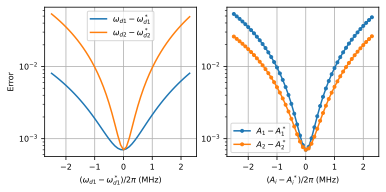

In [10]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(6,2.7))
ax[0].plot( 10**3 * detune_vec, error_w1, '-', label='$\omega_{d1} - \omega_{d1}^*$')
ax[0].plot( 10**3 * detune_vec, error_w2, '-', label='$\omega_{d2} - \omega_{d2}^*$')
ax[0].set_yscale('log')
ax[0].set_xlabel(r'$(\omega_{d1} - \omega_{d1}^*)/2\pi$ (MHz)')
ax[0].set_ylabel('Error')
ax[0].grid()
ax[0].legend()

ax[1].plot( 10**3 * A_vec, error_A1, '.-', label='$A_1 - A_1^*$')
ax[1].plot( 10**3 * A_vec, error_A2, '.-', label='$A_2 - A_2^*$')
ax[1].set_yscale('log')
ax[1].set_xlabel(r'$(A_i - A_i^*)/2\pi$ (MHz)')
ax[1].grid()
ax[1].legend()
# plt.savefig('cnot_fidelity_tg.png', dpi=300, bbox_inches='tight')

In [11]:
# error_vs_d_wd = np.column_stack((np.round(10**3 * detune_vec, 2), np.round(error_w1, 8), np.round(error_w2, 8)))
# columns = ['d_wd_vec',  'error_wd1', 'error_wd2']
# df = pd.DataFrame(error_vs_d_wd, columns=columns)
# df.to_csv('data/cnot_error_vs_d_wd.txt', sep=',', index=True, header=True)
# error_vs_A = np.column_stack((np.round(10**3 * A_vec, 2), np.round(error_A1, 8), np.round(error_A2, 8)))
# columns = ['dA_vec',  'error_A1', 'error_A2']
# df = pd.DataFrame(error_vs_A, columns=columns)
# df.to_csv('data/cnot_error_vs_dA.txt', sep=',', index=True, header=True)

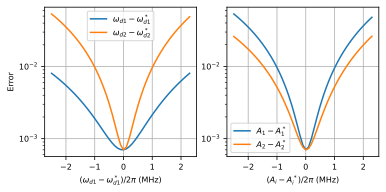

In [13]:
df_wd = pd.read_csv('data/data_fig/cnot_2A_tg180.72_error_vs_dwd.txt')
df_dA = pd.read_csv('data/data_fig/cnot_2A_tg180.72_error_vs_dA.txt')

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(6,2.7))
ax[0].plot( df_wd['d_wd_vec'], df_wd['error_wd1'], '-', label='$\omega_{d1} - \omega_{d1}^*$')
ax[0].plot( df_wd['d_wd_vec'], df_wd['error_wd2'], '-', label='$\omega_{d2} - \omega_{d2}^*$')
ax[0].set_yscale('log')
ax[0].set_xlabel(r'$(\omega_{d1} - \omega_{d1}^*)/2\pi$ (MHz)')
ax[0].set_ylabel('Error')
ax[0].grid()
ax[0].legend()

ax[1].plot( df_dA['dA_vec'], df_dA['error_A1'], '-', label='$A_1 - A_1^*$')
ax[1].plot( df_dA['dA_vec'], df_dA['error_A2'], '-', label='$A_2 - A_2^*$')
ax[1].set_yscale('log')
ax[1].set_xlabel(r'$(A_i - A_i^*)/2\pi$ (MHz)')
ax[1].grid()
ax[1].legend()
# plt.savefig('cnot_fidelity_tg.png', dpi=300, bbox_inches='tight')

## Infidelity(tg) - 1A0

[Parallel(n_jobs=51)]: Using backend LokyBackend with 51 concurrent workers.
[Parallel(n_jobs=51)]: Done   2 out of  51 | elapsed:    8.4s remaining:  3.4min
[Parallel(n_jobs=51)]: Done  51 out of  51 | elapsed:   17.7s finished


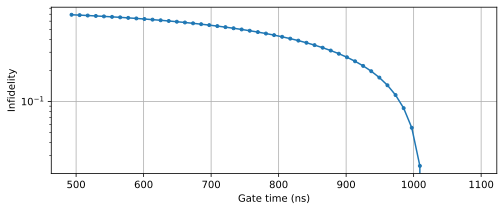

In [ ]:


t_vec = np.linspace(-300, 300, 51) + 793.22

values_grid = list(itertools.product([ 5.538e-03],  t_vec, [-3.9057e-04]))
fidelity = Parallel(n_jobs=len(t_vec), verbose=1)(delayed(ut.get_fidelity_cnot_1A0)(arg_de, *args)
                                            for arg_de in values_grid)
Infidelity = 1+np.array(fidelity)
fig, ax = plt.subplots(figsize=(8,3))
plt.plot(t_vec, Infidelity, '.-', label='infidelity')
plt.yscale('log')
plt.xlabel('Gate time (ns)')
plt.ylabel('Infidelity')
plt.grid()
# plt.savefig('cnot_fidelity_tg.png', dpi=300, bbox_inches='tight')

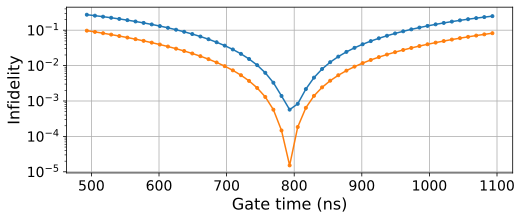

: 

In [ ]:
fig, ax = plt.subplots(figsize=(8,3))
plt.plot(t_vec, Infidelity, '.-', label='')
plt.plot(t_vec, Infidelity_2A0, '.-', label='infidelity')
plt.yscale('log')
plt.xlabel('Gate time (ns)')
plt.ylabel('Infidelity')
plt.grid()
# plt.savefig('cnot_fidelity_tg.png', dpi=300, bbox_inches='tight')

In [ ]:
=

## Chevron 1A - Fidelity around optimal points


### $t_g + \delta$

In [ ]:
drive_amp,  tg, detune = [0.0214, 218.4, -0.0058]
A_list = np.linspace(-0.018, 0.048, 21)
tg_list = np.linspace(-60, 60, 21)
detune_list = np.linspace(-0.0048, 0.0048, 21)
A_vec = drive_amp_A + A_list
tg_vec = tg + tg_list
detune_vec = detune_A + detune_list

values_grid = list(itertools.product([drive_amp], tg_vec, detune_vec))
fidelity = Parallel(n_jobs=150, verbose=1)(delayed(ut.get_fidelity_cnot_1A0)(arg_de, *args)
                                            for arg_de in values_grid)
Infidelity = 1+np.array(fidelity)
Infidelity = np.reshape(Infidelity, (len(A_vec), len(detune_vec)))

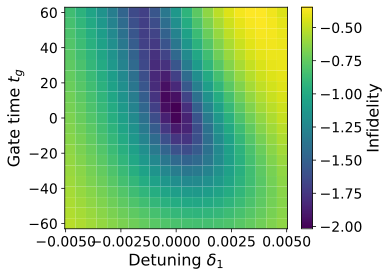

In [ ]:
# A_list = np.linspace(-0.018, 0.048, 21)
# tg_list = np.linspace(-60, 60, 21)
fig, ax = plt.subplots(figsize=(5,4))
plt.pcolormesh( detune_list, tg_list, np.log10(Infidelity))
plt.xlabel('Detuning $\delta_1$')
plt.ylabel('Gate time $t_g$')
plt.colorbar(label='Infidelity')
# plt.savefig('cnot_fidelity_tg.png', dpi=300, bbox_inches='tight')

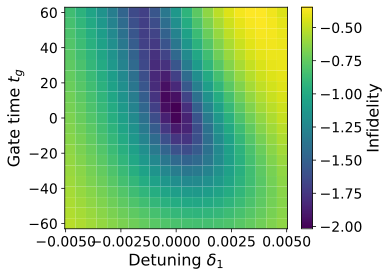

In [ ]:
# A_list = np.linspace(-0.018, 0.048, 21)
# tg_list = np.linspace(-60, 60, 21)
fig, ax = plt.subplots(figsize=(5,4))
plt.pcolormesh( detune_list, tg_list, np.log10(Infidelity))
plt.xlabel('Detuning $\delta_1$')
plt.ylabel('Gate time $t_g$')
plt.colorbar(label='Infidelity')
# plt.savefig('cnot_fidelity_tg.png', dpi=300, bbox_inches='tight')

In [ ]:
drive_amp,  tg, detune = [0.0214, 218.4, -0.0058]
A_list = np.linspace(-0.018, 0.048, 21)
tg_list = np.linspace(-60, 60, 21)
detune_list = np.linspace(-0.0048, 0.0048, 21)
A_vec = drive_amp_A + A_list
tg_vec = tg + tg_list
detune_vec = detune_A + detune_list

values_grid = list(itertools.product(A_vec, [tg], detune_vec))
fidelity = Parallel(n_jobs=150, verbose=1)(delayed(ut.get_fidelity_cnot_1A0)(arg_de, *args)
                                            for arg_de in values_grid)
Infidelity = 1+np.array(fidelity)
Infidelity = np.reshape(Infidelity, (len(A_vec), len(detune_vec)))

[Parallel(n_jobs=150)]: Using backend LokyBackend with 150 concurrent workers.
[Parallel(n_jobs=150)]: Done 441 out of 441 | elapsed:   34.2s finished


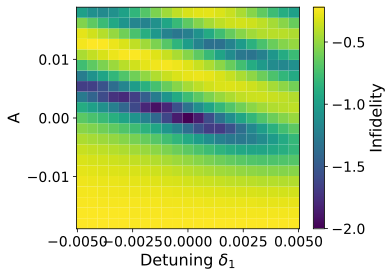

In [ ]:
# A_list = np.linspace(-0.018, 0.048, 21)
# tg_list = np.linspace(-60, 60, 21)
fig, ax = plt.subplots(figsize=(5,4))
plt.pcolormesh( detune_list, A_list, np.log10(Infidelity))
plt.xlabel('Detuning $\delta_1$')
plt.ylabel('A')
plt.colorbar(label='Infidelity')
# plt.savefig('cnot_fidelity_tg.png', dpi=300, bbox_inches='tight')

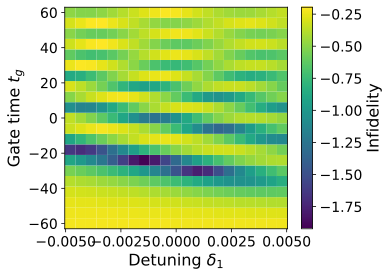

In [ ]:
# A_list = np.linspace(-0.018, 0.048, 21)
# tg_list = np.linspace(-60, 60, 21)
fig, ax = plt.subplots(figsize=(5,4))
plt.pcolormesh( detune_list, tg_list, np.log10(Infidelity))
plt.xlabel('Detuning $\delta_1$')
plt.ylabel('Gate time $t_g$')
plt.colorbar(label='Infidelity')
# plt.savefig('cnot_fidelity_tg.png', dpi=300, bbox_inches='tight')

### $A+t_g$

In [ ]:
drive_amp_A, drive_amp_B, tg, detune_A, detune_B = [0.0214, 0.0214, 218.4, -0.0058, -0.0058]
A_list = np.linspace(-0.018, 0.048, 21)
tg_list = np.linspace(-60, 60, 21)
detune_list = np.linspace(-0.0048, 0.0048, 21)
A_vec = drive_amp_A + A_list
tg_vec = tg + tg_list
detune_vec = detune_A + detune_list

values_grid = list(itertools.product(A_vec, [drive_amp_B], tg_vec, [detune_A], [detune_B]))
fidelity = Parallel(n_jobs=150, verbose=1)(delayed(ut.get_fidelity_cnot_2A0)(arg_de, *args)
                                            for arg_de in values_grid)
Infidelity = 1+np.array(fidelity)
Infidelity = np.reshape(Infidelity, (len(A_vec), len(detune_vec)))

[Parallel(n_jobs=150)]: Using backend LokyBackend with 150 concurrent workers.
[Parallel(n_jobs=150)]: Done 441 out of 441 | elapsed:   27.4s finished


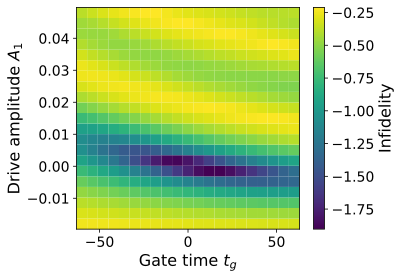

In [ ]:
# A_list = np.linspace(-0.018, 0.048, 21)
# tg_list = np.linspace(-60, 60, 21)
fig, ax = plt.subplots(figsize=(5,4))
plt.pcolormesh(tg_list, A_list,  np.log10(Infidelity))
plt.ylabel('Drive amplitude $A_1$')
plt.xlabel('Gate time $t_g$')
plt.colorbar(label='Infidelity')
# plt.savefig('cnot_fidelity_tg.png', dpi=300, bbox_inches='tight')

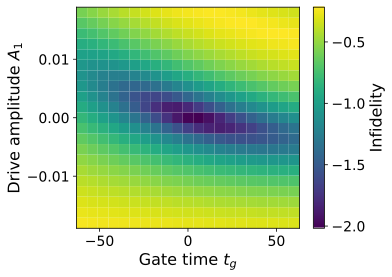

In [ ]:
# A_list = np.linspace(-0.018, 0.018, 21)
# tg_list = np.linspace(-60, 60, 21)
fig, ax = plt.subplots(figsize=(5,4))
plt.pcolormesh(tg_list, A_list,  np.log10(Infidelity))
plt.ylabel('Drive amplitude $A_1$')
plt.xlabel('Gate time $t_g$')
plt.colorbar(label='Infidelity')
# plt.savefig('cnot_fidelity_tg.png', dpi=300, bbox_inches='tight')

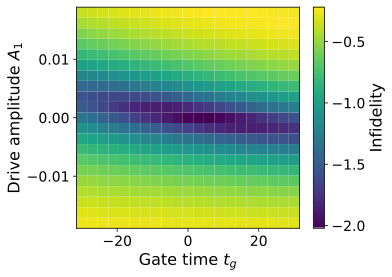

In [ ]:
# A_list = np.linspace(-0.018, 0.018, 21)
# tg_list = np.linspace(-30, 30, 21)
fig, ax = plt.subplots(figsize=(5,4))
plt.pcolormesh(tg_list, A_list,  np.log10(Infidelity))
plt.ylabel('Drive amplitude $A_1$')
plt.xlabel('Gate time $t_g$')
plt.colorbar(label='Infidelity')
# plt.savefig('cnot_fidelity_tg.png', dpi=300, bbox_inches='tight')

### $A+\delta$

In [ ]:
drive_amp_A, drive_amp_B, tg, detune_A, detune_B = [0.0214, 0.0214, 218.4, -0.0058, -0.0058]
A_list = np.linspace(-0.018, 0.018, 21)
tg_list = np.linspace(-30, 30, 21)
detune_list = np.linspace(-0.0048, 0.0048, 21)
A_vec = drive_amp_A + A_list
tg_vec = tg + tg_list
detune_vec = detune_A + detune_list

values_grid = list(itertools.product(A_vec, [drive_amp_B], tg_vec, [detune_A], [detune_B]))
fidelity = Parallel(n_jobs=150, verbose=1)(delayed(ut.get_fidelity_cnot_2A0)(arg_de, *args)
                                            for arg_de in values_grid)
Infidelity = 1+np.array(fidelity)
Infidelity = np.reshape(Infidelity, (len(A_vec), len(detune_vec)))

[Parallel(n_jobs=150)]: Using backend LokyBackend with 150 concurrent workers.
[Parallel(n_jobs=150)]: Done 441 out of 441 | elapsed:   33.7s finished


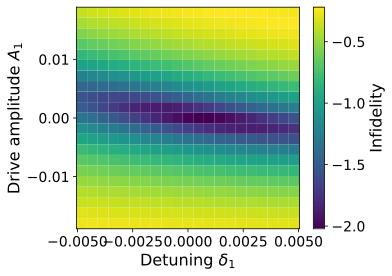

In [ ]:
fig, ax = plt.subplots(figsize=(5,4))
plt.pcolormesh(detune_list, A_list,  np.log10(Infidelity))
plt.ylabel('Drive amplitude $A_1$')
plt.xlabel('Detuning $\delta_1$')
plt.colorbar(label='Infidelity')
# plt.savefig('cnot_fidelity_tg.png', dpi=300, bbox_inches='tight')

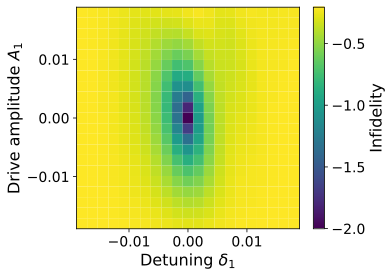

In [ ]:
fig, ax = plt.subplots(figsize=(5,4))
plt.pcolormesh(A_list, detune_list, np.log10(Infidelity))
plt.ylabel('Drive amplitude $A_1$')
plt.xlabel('Detuning $\delta_1$')
plt.colorbar(label='Infidelity')
# plt.savefig('cnot_fidelity_tg.png', dpi=300, bbox_inches='tight')

## Chevron 2A


In [ ]:
[drive_amp_A, drive_amp_B, tg, detune_A,
 detune_B] = [0.07535164387311441, 0.061356834821833434, 97.14285659900979, -0.2572535189807941, -0.2535300334474417]

arg_de = drive_amp_A, drive_amp_B, tg, detune_A, detune_B
infidelity = ut.get_fidelity_cnot_2A0(arg_de, *args)
infidelity

-1.7907900871182434

: 

## Sweep

In [ ]:
drive_amp_A, drive_amp_B, tg, detune_A, detune_B = [0.0656, 0.03256, 255.85, -0.033096, -0.03658]
A_vec = drive_amp_A + np.linspace(-0.009, 0.009, 21)
detune_vec = detune_A + np.linspace(-0.006, 0.006, 21)

values_grid = list(itertools.product(A_vec, [0.03256], [255.85], detune_vec, [-0.03658]))
fidelity = Parallel(n_jobs=150, verbose=1)(delayed(ut.get_fidelity_cnot_2A0)(arg_de, *args)
                                            for arg_de in values_grid)
Infidelity = 1+np.array(fidelity)
Infidelity = np.reshape(Infidelity, (len(A_vec), len(detune_vec)))

[Parallel(n_jobs=150)]: Using backend LokyBackend with 150 concurrent workers.
[Parallel(n_jobs=150)]: Done 441 out of 441 | elapsed:   32.0s finished


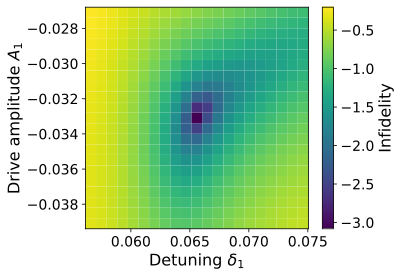

In [ ]:
fig, ax = plt.subplots(figsize=(5,4))
plt.pcolormesh(A_vec, detune_vec, np.log10(Infidelity))
plt.ylabel('Drive amplitude $A_1$')
plt.xlabel('Detuning $\delta_1$')
plt.colorbar(label='Infidelity')
# plt.savefig('cnot_fidelity_tg.png', dpi=300, bbox_inches='tight')